In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/vaishnavishinde304/skin-disease-dataset/skin_diseases_split/test/Light Diseases and Disorders of Pigmentation/phototoxic-reactions-20.jpg
/kaggle/input/datasets/vaishnavishinde304/skin-disease-dataset/skin_diseases_split/test/Light Diseases and Disorders of Pigmentation/phototoxic-reactions-2.jpg
/kaggle/input/datasets/vaishnavishinde304/skin-disease-dataset/skin_diseases_split/test/Light Diseases and Disorders of Pigmentation/porphyrias-11.jpg
/kaggle/input/datasets/vaishnavishinde304/skin-disease-dataset/skin_diseases_split/test/Light Diseases and Disorders of Pigmentation/phototoxic-reactions-84.jpg
/kaggle/input/datasets/vaishnavishinde304/skin-disease-dataset/skin_diseases_split/test/Light Diseases and Disorders of Pigmentation/polymorphous-light-eruption-25.jpg
/kaggle/input/datasets/vaishnavishinde304/skin-disease-dataset/skin_diseases_split/test/Light Diseases and Disorders of Pigmentation/sun-damaged-skin-131.jpg
/kaggle/input/datasets/vaishnavishinde304

In [33]:
model_checkpoint = "facebook/dinov2-base" # pre-trained model from which to fine-tune

In [4]:
!pip install -q datasets transformers

In [5]:
! pip install -U accelerate
! pip install -U transformers

In [34]:
from huggingface_hub import notebook_login

notebook_login()

In [35]:
%%capture
!sudo apt -qq install git-lfs
!git config --global credential.helper store

In [36]:
from datasets import load_dataset
dataset = load_dataset("imagefolder", data_dir="/kaggle/input/datasets/vaishnavishinde304/skin-disease-dataset")

Resolving data files:   0%|          | 0/13460 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/3374 [00:00<?, ?it/s]

In [9]:
!pip install evaluate

In [37]:
import evaluate

# Replace load_metric with evaluate.load
metric = evaluate.load("accuracy")

In [38]:
dataset

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 13460
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 3374
    })
})

In [39]:
dataset["train"].features

{'image': Image(mode=None, decode=True),
 'label': ClassLabel(names=['Acne and Rosacea Photos', 'Actinic Keratosis Basal Cell Carcinoma and other Malignant Lesions', 'Atopic Dermatitis Photos', 'Bullous Disease Photos', 'Cellulitis Impetigo and other Bacterial Infections', 'Eczema Photos', 'Exanthems and Drug Eruptions', 'Hair Loss Photos Alopecia and other Hair Diseases', 'Herpes HPV and other STDs Photos', 'Light Diseases and Disorders of Pigmentation', 'Lupus and other Connective Tissue diseases', 'Melanoma Skin Cancer Nevi and Moles', 'Monkeypox', 'Nail Fungus and other Nail Disease', 'Psoriasis pictures Lichen Planus and related diseases', 'Scabies Lyme Disease and other Infestations and Bites', 'Seborrheic Keratoses and other Benign Tumors', 'Systemic Disease', 'Tinea Ringworm Candidiasis and other Fungal Infections', 'Vascular Tumors', 'Vasculitis Photos', 'Warts Molluscum and other Viral Infections', 'normal skin'])}

In [40]:
example = dataset["train"][10]
example

{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=720x472>,
 'label': 0}

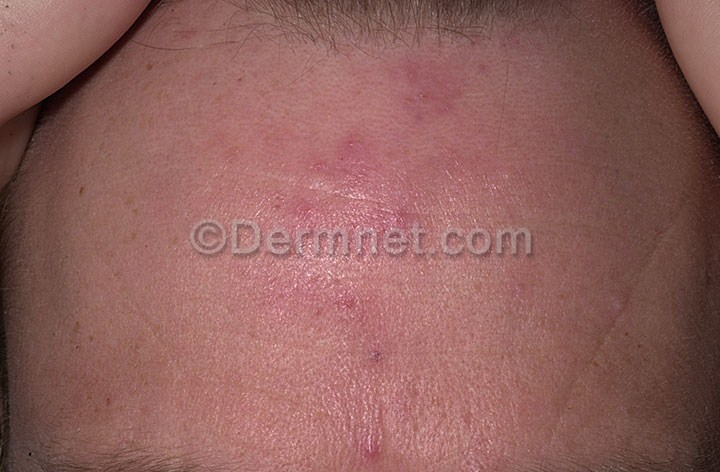

In [41]:
example['image']

In [42]:
example['label']

0

In [16]:
dataset["train"].features["label"]

ClassLabel(names=['Acne and Rosacea Photos', 'Actinic Keratosis Basal Cell Carcinoma and other Malignant Lesions', 'Atopic Dermatitis Photos', 'Bullous Disease Photos', 'Cellulitis Impetigo and other Bacterial Infections', 'Eczema Photos', 'Exanthems and Drug Eruptions', 'Hair Loss Photos Alopecia and other Hair Diseases', 'Herpes HPV and other STDs Photos', 'Light Diseases and Disorders of Pigmentation', 'Lupus and other Connective Tissue diseases', 'Melanoma Skin Cancer Nevi and Moles', 'Monkeypox', 'Nail Fungus and other Nail Disease', 'Psoriasis pictures Lichen Planus and related diseases', 'Scabies Lyme Disease and other Infestations and Bites', 'Seborrheic Keratoses and other Benign Tumors', 'Systemic Disease', 'Tinea Ringworm Candidiasis and other Fungal Infections', 'Vascular Tumors', 'Vasculitis Photos', 'Warts Molluscum and other Viral Infections', 'normal skin'])

In [43]:
labels = dataset["train"].features["label"].names
label2id, id2label = dict(), dict()
for i, label in enumerate(labels):
    label2id[label] = i
    id2label[i] = label

id2label[2]

'Atopic Dermatitis Photos'

In [44]:
from transformers import AutoImageProcessor

image_processor  = AutoImageProcessor.from_pretrained(model_checkpoint)
image_processor

BitImageProcessor {
  "crop_size": {
    "height": 224,
    "width": 224
  },
  "do_center_crop": true,
  "do_convert_rgb": true,
  "do_normalize": true,
  "do_rescale": true,
  "do_resize": true,
  "image_mean": [
    0.485,
    0.456,
    0.406
  ],
  "image_processor_type": "BitImageProcessor",
  "image_std": [
    0.229,
    0.224,
    0.225
  ],
  "resample": 3,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "shortest_edge": 256
  }
}

In [45]:
from torchvision.transforms import (
    CenterCrop,
    Compose,
    Normalize,
    RandomHorizontalFlip,
    RandomResizedCrop,
    Resize,
    ToTensor,
)

normalize = Normalize(mean=image_processor.image_mean, std=image_processor.image_std)
if "height" in image_processor.size:
    size = (image_processor.size["height"], image_processor.size["width"])
    crop_size = size
    max_size = None
elif "shortest_edge" in image_processor.size:
    size = image_processor.size["shortest_edge"]
    crop_size = (size, size)
    max_size = image_processor.size.get("longest_edge")

train_transforms = Compose(
        [
            RandomResizedCrop(crop_size),
            RandomHorizontalFlip(),
            ToTensor(),
            normalize,
        ]
    )

val_transforms = Compose(
        [
            Resize(size),
            CenterCrop(crop_size),
            ToTensor(),
            normalize,
        ]
    )

def preprocess_train(example_batch):
    """Apply train_transforms across a batch."""
    example_batch["pixel_values"] = [
        train_transforms(image.convert("RGB")) for image in example_batch["image"]
    ]
    return example_batch

def preprocess_val(example_batch):
    """Apply val_transforms across a batch."""
    example_batch["pixel_values"] = [val_transforms(image.convert("RGB")) for image in example_batch["image"]]
    return example_batch

In [46]:
# split up training into training + validation
splits = dataset["train"].train_test_split(test_size=0.1)
train_ds = splits['train']
val_ds = splits['test']

In [47]:
train_ds.set_transform(preprocess_train)
val_ds.set_transform(preprocess_val)

In [48]:
from transformers import AutoModelForImageClassification, TrainingArguments, Trainer

model = AutoModelForImageClassification.from_pretrained(
    model_checkpoint,
    label2id=label2id,
    id2label=id2label,
    ignore_mismatched_sizes = True, # provide this in case you're planning to fine-tune an already fine-tuned checkpoint
)

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Dinov2ForImageClassification LOAD REPORT from: facebook/dinov2-base
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [49]:
import accelerate
import transformers

transformers.__version__, accelerate.__version__

('5.5.0', '1.13.0')

In [ ]:
args = TrainingArguments(
    f"dinov2-finetuned-skin-disease",
    remove_unused_columns=False,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=5e-5,
    per_device_train_batch_size= 16,
    gradient_accumulation_steps=8,      # Increased to balance the smaller batch
    per_device_eval_batch_size= 16,
    num_train_epochs=8,
    warmup_steps=500,
    logging_steps=10,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    fp16=True,                          
    push_to_hub=False,
)

In [51]:
train_ds[0]

{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=224x224>,
 'label': 12,
 'pixel_values': tensor([[[ 1.8722,  1.5639,  1.1015,  ...,  1.1015,  0.9988,  0.9474],
          [ 1.1872,  1.1187,  1.0331,  ...,  1.1529,  0.9988,  0.9132],
          [ 0.8276,  0.9132,  1.0844,  ...,  1.0673,  0.9474,  0.8789],
          ...,
          [-0.0116,  0.0056,  0.0398,  ..., -0.9020, -0.7479, -0.6281],
          [ 0.1254,  0.1939,  0.2796,  ..., -0.8678, -0.6794, -0.5424],
          [ 0.2453,  0.3309,  0.4508,  ..., -0.8849, -0.7308, -0.6281]],
 
         [[ 1.1506,  0.9055,  0.5028,  ...,  0.0301, -0.0749, -0.1275],
          [ 0.4503,  0.4503,  0.4328,  ...,  0.0651, -0.0574, -0.1450],
          [ 0.0651,  0.2227,  0.4678,  ..., -0.0224, -0.1099, -0.1800],
          ...,
          [-0.3725, -0.4251, -0.4951,  ..., -1.0728, -0.8627, -0.7402],
          [-0.3025, -0.3025, -0.3025,  ..., -1.0553, -0.8277, -0.6877],
          [-0.2500, -0.2150, -0.1625,  ..., -1.0728, -0.9153, -0.8102]

In [52]:
import numpy as np

# the compute_metrics function takes a Named Tuple as input:
# predictions, which are the logits of the model as Numpy arrays,
# and label_ids, which are the ground-truth labels as Numpy arrays.
def compute_metrics(eval_pred):
    """Computes accuracy on a batch of predictions"""
    predictions = np.argmax(eval_pred.predictions, axis=1)
    return metric.compute(predictions=predictions, references=eval_pred.label_ids)

In [53]:
import torch

def collate_fn(examples):
    pixel_values = torch.stack([example["pixel_values"] for example in examples])
    labels = torch.tensor([example["label"] for example in examples])
    return {"pixel_values": pixel_values, "labels": labels}

In [54]:
trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    processing_class=image_processor, 
    compute_metrics=compute_metrics,
    data_collator=collate_fn,
)

In [ ]:

train_results = trainer.train()
# rest is optional but nice to have
trainer.save_model()
trainer.log_metrics("train", train_results.metrics)
trainer.save_metrics("train", train_results.metrics)
trainer.save_state()

In [ ]:
metrics = trainer.evaluate()
# some nice to haves:
trainer.log_metrics("eval", metrics)
trainer.save_metrics("eval", metrics)

In [ ]:
trainer.push_to_hub()

In [ ]:
test_ds

In [ ]:
from transformers import AutoModelForImageClassification, AutoImageProcessor
from sklearn.metrics import accuracy_score
import torch

# Load the pre-trained model and image processor
repo_name = "Jayanth2002/dinov2-base-rawdata-finetuned-SkinDisease"
image_processor = AutoImageProcessor.from_pretrained(repo_name)
model = AutoModelForImageClassification.from_pretrained(repo_name)

# Load and preprocess the test images
test_data_dir = "/kaggle/input/raw-paper/test"  # Path to the test data directory
test_images = load_dataset("imagefolder", data_dir=test_data_dir)

# Preprocess the test images
test_images.set_transform(preprocess_val)  # Use the same validation transforms

# Create a test dataset
test_ds = test_images["train"]  # Use the "train" split for the test data

In [ ]:
# Initialize lists to store predicted and actual labels
predicted_labels = []
actual_labels = []

# Iterate through the test dataset and make predictions
for example in test_ds:
    image = example["image"]
    encoding = image_processor(image.convert("RGB"), return_tensors="pt")

    with torch.no_grad():
        outputs = model(**encoding)
        logits = outputs.logits

    predicted_class_idx = logits.argmax(-1).item()
    predicted_labels.append(predicted_class_idx)
    actual_labels.append(example["label"])

# Calculate accuracy
accuracy = accuracy_score(actual_labels, predicted_labels)

print(f"Test Accuracy: {accuracy:.4f}")